### Load and preprocess MovieLens 32M dataset

This cell loads the MovieLens 32M ratings data and performs initial preprocessing to prepare it for modelling.

User and item identifiers are remapped to contiguous zero-based indices to ensure efficient indexing in subsequent matrix operations. The dataset is then shuffled to remove any ordering effects.

Finally, user-wise and item-wise rating lists are constructed to support fast access during model training and evaluation.

In [1]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Load data
ratings = pd.read_csv("../data/ml-32m/ratings.csv")
movies = pd.read_csv("../data/ml-32m/movies.csv")
data = ratings.iloc[:, : -1]

# Maximum user ID
max_users = np.max(data.iloc[:, 0])

# Get unique users in order
unique_users_ordered = pd.unique(data.iloc[:, 0])

# Filter data to include only unique users
filtered_data = data[data.iloc[:, 0].isin(unique_users_ordered)].copy()

# Map old user IDs to new sequential IDs
user_id_map = {old: new for new, old in enumerate(unique_users_ordered)}
filtered_data.iloc[:, 0] = filtered_data.iloc[:, 0].map(user_id_map)

# Map old item IDs to new sequential IDs
unique_items = filtered_data.iloc[:, 1].unique()
item_id_map = {old: new for new, old in enumerate(unique_items)}
filtered_data.iloc[:, 1] = filtered_data.iloc[:, 1].map(item_id_map)

# Shuffle data
filtered_data = filtered_data.sample(frac=1, random_state=99).reset_index(drop=True)

# Number of users, items, and ratings
n_users = filtered_data.iloc[:, 0].nunique()
n_items = filtered_data.iloc[:, 1].nunique()
n_ratings = len(filtered_data)

# Initialize rating lists
user_ratings = [[] for _ in range(n_users)]
item_ratings = [[] for _ in range(n_items)]

# Populate rating lists
for user, item, rating in tqdm(filtered_data.iloc[:n_ratings, :].values):
    user_ratings[int(user)].append((int(item), float(rating)))
    item_ratings[int(item)].append((int(user), float(rating)))


100%|██████████| 32000204/32000204 [01:00<00:00, 531289.98it/s]


### Load trained model parameters

This cell loads previously saved model parameters and training history from disk.

The stored arrays include user and item biases, latent embeddings, feature embeddings, and optimisation curves such as negative log-likelihood and RMSE over iterations. These allow the model to be reused without retraining.

The training mean rating is recomputed from the current dataset to ensure consistency when making predictions with the loaded parameters.

In [2]:
# Load additional data
data = np.load("../model/all_data.npz", allow_pickle=True)

# Extract arrays from loaded data
user_bias = data["user_bias"]
item_bias = data["item_bias"]
user_embedding = data["user_embedding"]
item_embedding = data["item_embedding"]
feature_embedding = data["feature_embedding"]
nll_history = data["nll_history"]
train_rmse_history = data["train_rmse_history"]
test_rmse_history = data["test_rmse_history"]
item_id_map = data["item_id_map"]

# Compute mean of training ratings
mu_train = filtered_data.iloc[:, 2].mean()


### Convergence diagnostics

This cell visualises the optimisation behaviour of the trained model across iterations.

The first plot shows the evolution of the negative log-likelihood, providing insight into whether the model is converging smoothly during training.

The second plot compares training and test RMSE over iterations, allowing assessment of generalisation performance and potential overfitting as the optimisation progresses.

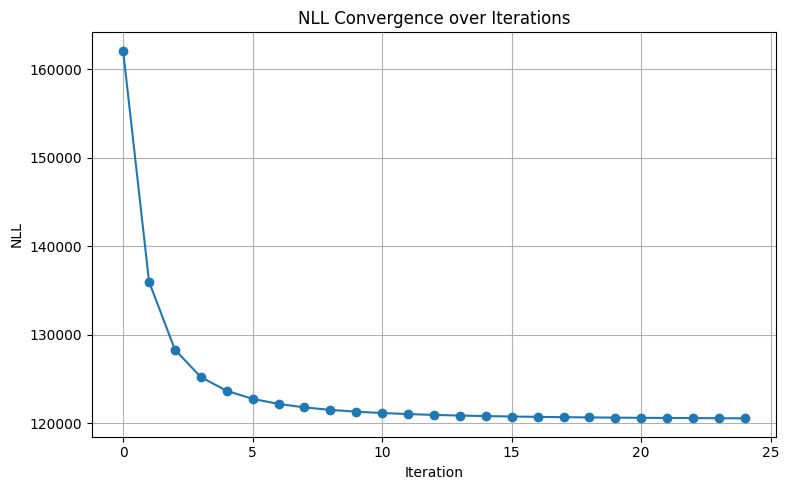

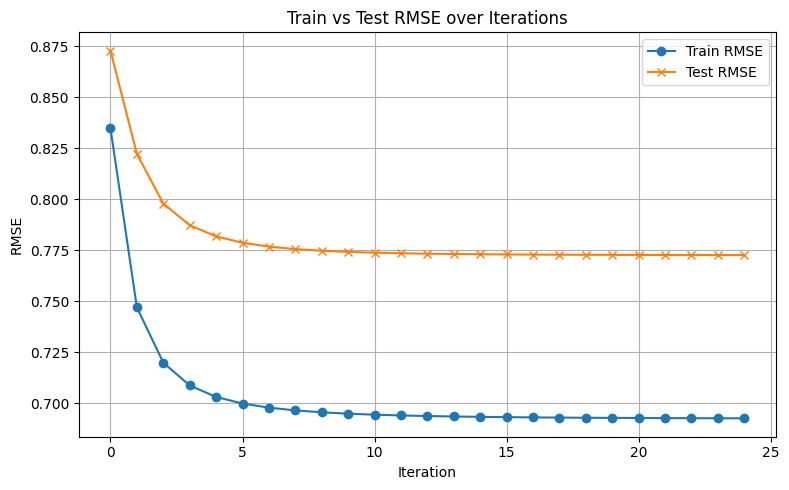

In [3]:
import matplotlib.pyplot as plt

# Plot NLL convergence over iterations
plt.figure(figsize=(8, 5))
plt.plot(nll_history, marker="o")
plt.xlabel("Iteration")
plt.ylabel("NLL")
plt.title("NLL Convergence over Iterations")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Train vs Test RMSE over iterations
plt.figure(figsize=(8, 5))
plt.plot(train_rmse_history, label="Train RMSE", marker="o")
plt.plot(test_rmse_history, label="Test RMSE", marker="x")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.title("Train vs Test RMSE over Iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Clean and enrich movie metadata

This cell processes the movie metadata by mapping movie IDs to titles, cleaning genre labels, and extracting additional temporal features.

In particular, movie release years are extracted from titles and used to construct a decade variable (with a special grouping for films released before the 1950s). Missing values are handled explicitly to ensure consistency in later feature encoding and modelling steps.

In [4]:
from utils import extract_year

# Map movie IDs to titles
movieid_to_title = dict(zip(movies['movieId'], movies['title']))

# Convert genre strings to lists and clean out missing/invalid genre labels
movies['genres'] = movies['genres'].str.split('|').apply(
    lambda lst: [g for g in lst if g != '(no genres listed)']
)

# Extract year and compute decade
movies['year'] = movies['title'].map(extract_year)
movies['decade'] = ((movies['year'] // 10) * 10).astype('Int64')
movies['decade'] = movies['decade'].astype('string') + "s"
movies.loc[movies['year'] < 1950, 'decade'] = 'pre 1950s'

# Ensure decade is string and handle missing values
movies['decade'] = movies['decade'].astype('string')
movies['decade'] = movies['decade'].where(movies['decade'].notna(), None)

# Fill missing decade for encoding
movies['decade'] = movies['decade'].fillna('SKIP_THIS')

# Select relevant columns
movies = movies[['movieId', 'title', 'genres', 'decade']]

### Construct item feature matrix

This cell builds a feature representation for each movie by combining genre and decade information.

Genres are encoded using a multi-hot representation, allowing each movie to belong to multiple genre categories simultaneously. Decades are encoded using one-hot encoding over valid time periods, capturing temporal structure in the catalogue.

The resulting feature matrix concatenates both representations into a single item-level feature space, which will later be used for modelling and analysis.

In [5]:
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder

# Multi-hot encode genres
mlb = MultiLabelBinarizer()
genre_features = mlb.fit_transform(movies['genres'])

# One-hot encode decades
valid_decades = sorted([d for d in movies['decade'].dropna().unique() if d != 'SKIP_THIS'])
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', categories=[valid_decades])
decade_features = ohe.fit_transform(movies[['decade']])

# Combine genre and decade features
item_features = np.hstack([genre_features, decade_features])

# Feature names
decade_feature_names = [f"decade_{d}" for d in valid_decades]
genre_feature_names = [f"genre_{g}" for g in mlb.classes_]
feature_names = genre_feature_names + decade_feature_names

### Visualising learned feature embeddings (PCA projection)

This cell visualises the learned feature embeddings by projecting them into two dimensions using PCA.

The feature embedding matrix is split into:
- genre embeddings, and  
- decade embeddings,

which are then combined and reduced to a 2D representation for visual inspection.

The resulting plot provides an interpretable view of how the model has organised feature space, allowing qualitative assessment of relationships between genres and decades in the learned representation. Text labels are adjusted to reduce overlap for readability.

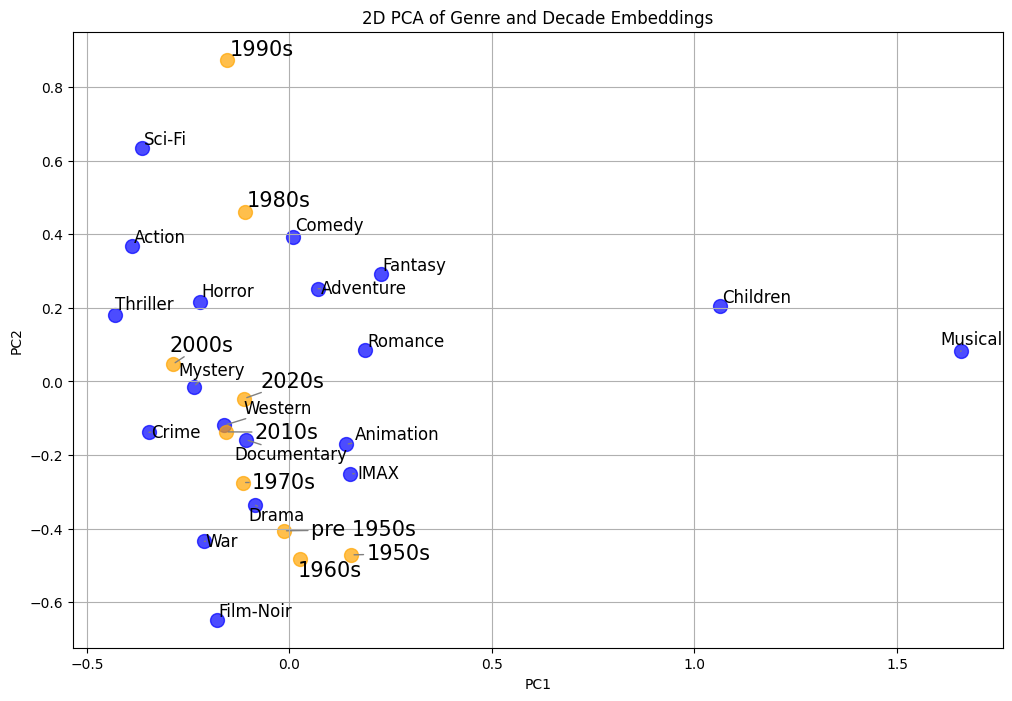

In [6]:
from sklearn.decomposition import PCA
from adjustText import adjust_text

# Map item indices to movieIds and titles
item_index_to_movieid = {v: k for k, v in item_id_map.item().items()}
item_index_to_title = {
    idx: movieid_to_title[movieid]
    for idx, movieid in item_index_to_movieid.items()
}

# Number of genre features
n_genres = len(mlb.classes_)

# Select only genre embeddings
genre_embedding = feature_embedding[:n_genres, :]

# Number of decades
n_decades = len(ohe.categories_[0])

# Select only decade embeddings
decade_embedding = feature_embedding[-n_decades:, :]

# Combine genre and decade embeddings
combined_embedding = np.vstack([genre_embedding, decade_embedding])

# Reduce to 2D using PCA
pca = PCA(n_components=2)
combined_emb_2d = pca.fit_transform(combined_embedding)

genre_emb_2d = combined_emb_2d[:n_genres, :]
decade_emb_2d = combined_emb_2d[n_genres:, :]

# Plot 2D PCA
plt.figure(figsize=(12, 8))

# Scatter points
plt.scatter(genre_emb_2d[:, 0], genre_emb_2d[:, 1], s=100, color="blue", alpha=0.7)
plt.scatter(decade_emb_2d[:, 0], decade_emb_2d[:, 1], s=100, color="orange", alpha=0.7)

# Add text labels
texts = []
for i, genre in enumerate(mlb.classes_):
    texts.append(plt.text(genre_emb_2d[i, 0], genre_emb_2d[i, 1], genre, fontsize=12))

for i, decade in enumerate(ohe.categories_[0]):
    texts.append(plt.text(decade_emb_2d[i, 0], decade_emb_2d[i, 1], decade, fontsize=15))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray"))

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA of Genre and Decade Embeddings")
plt.grid(True)
plt.show()

### Visualising movie embeddings for popular items

This cell examines the learned item embeddings for a subset of the most frequently rated movies.

The movies are ranked by number of ratings, and the most popular items are selected for visualisation. Their embeddings are then projected into two dimensions using PCA.

This provides a qualitative view of how the model organises highly-rated movies in latent space, with labels included to allow interpretation of individual points.

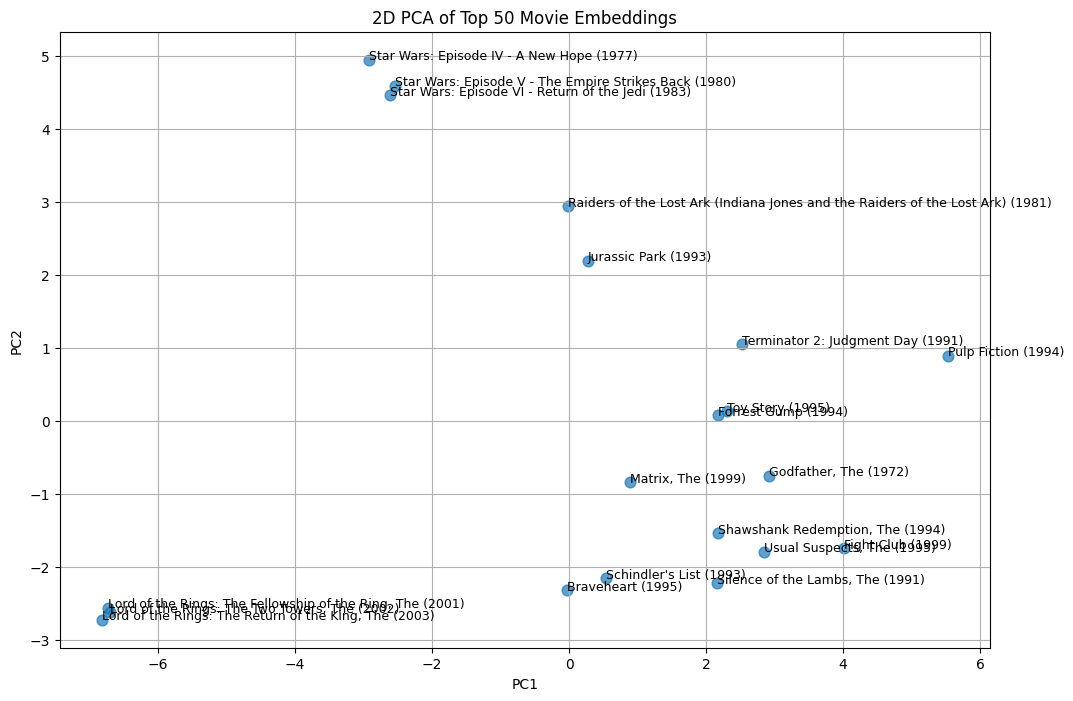

In [7]:
# Count number of ratings per item
item_counts = np.array([len(r) for r in item_ratings])

# Indices of top 50 most-rated movies
top_indices = item_counts.argsort()[::-1][:20]

# Embeddings for top 50 movies
top_embeddings = item_embedding[top_indices]

# Reduce embeddings to 2D using PCA
pca = PCA(n_components=2)
item_emb_2d = pca.fit_transform(top_embeddings)

# Plot 2D PCA of top movies
plt.figure(figsize=(12, 8))
plt.scatter(item_emb_2d[:, 0], item_emb_2d[:, 1], s=60, alpha=0.7)

# Add movie titles as labels
for i, idx in enumerate(top_indices):
    plt.text(item_emb_2d[i, 0], item_emb_2d[i, 1],
             item_index_to_title[idx], fontsize=9)

plt.title("2D PCA of Top 50 Movie Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()


### Similarity structure of learned feature embeddings

This cell analyses the relationships between learned feature embeddings using cosine similarity.

Three similarity matrices are constructed and visualised as heatmaps:
- **Genre vs Decade**: shows how different genres align with historical time periods,
- **Genre vs Genre**: captures relationships between different film genres,
- **Decade vs Decade**: highlights temporal similarity structure across eras.

The resulting visualisations provide insight into how the model encodes semantic structure within the feature space.

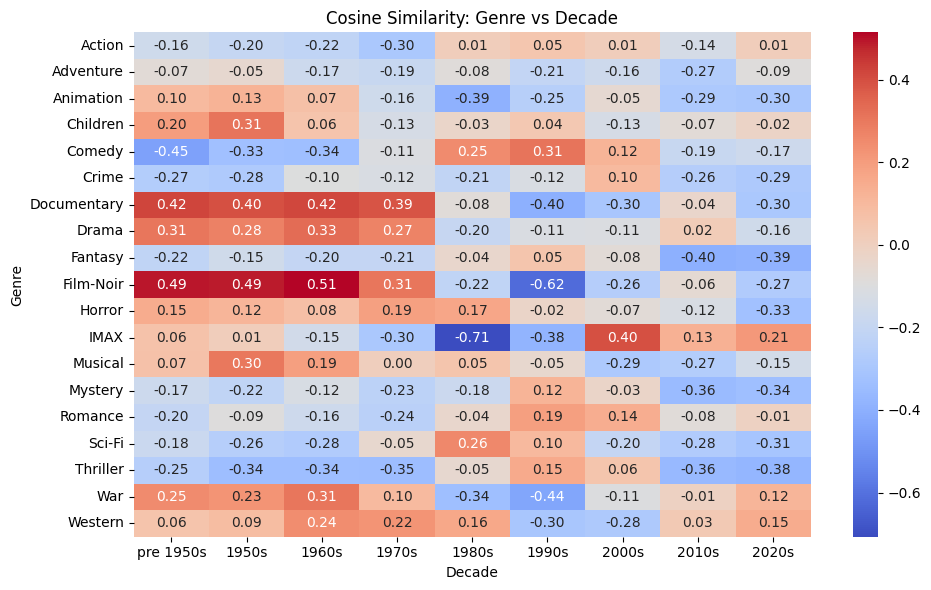

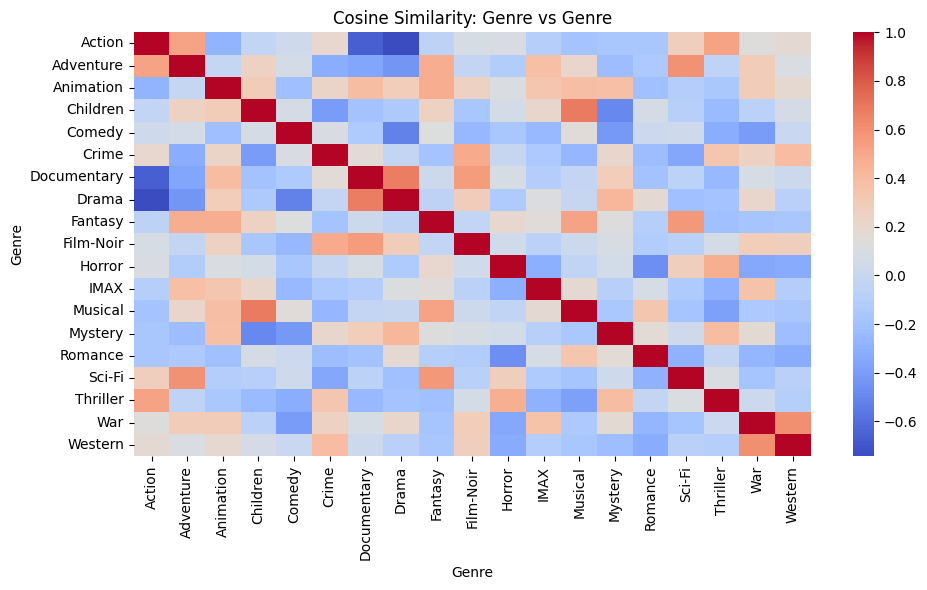

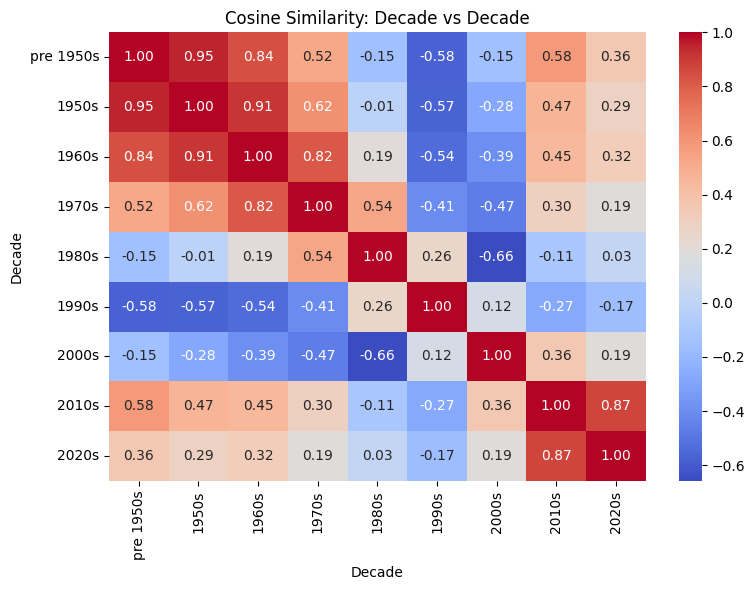

In [8]:
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

# Reorder decades
decades = list(ohe.categories_[0])
pre_idx = decades.index("pre 1950s")
decades = ["pre 1950s"] + [d for i, d in enumerate(decades) if i != pre_idx]

# Select decade embeddings and reorder
decade_embedding = feature_embedding[-n_decades:, :]
decade_embedding = np.vstack([
    decade_embedding[pre_idx, :],
    np.delete(decade_embedding, pre_idx, axis=0)
])


# Genre vs Decade
genre_decade_sim = cosine_similarity(genre_embedding, decade_embedding)
genre_decade_df = pd.DataFrame(genre_decade_sim, index=mlb.classes_, columns=decades)

plt.figure(figsize=(10, 6))
sns.heatmap(genre_decade_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Cosine Similarity: Genre vs Decade")
plt.xlabel("Decade")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


# Genre vs Genre
genre_genre_sim = cosine_similarity(genre_embedding)
genre_genre_df = pd.DataFrame(genre_genre_sim, index=mlb.classes_, columns=mlb.classes_)

plt.figure(figsize=(10, 6))
sns.heatmap(genre_genre_df, annot=False, cmap="coolwarm", cbar=True)
plt.title("Cosine Similarity: Genre vs Genre")
plt.xlabel("Genre")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


# Decade vs Decade
decade_decade_sim = cosine_similarity(decade_embedding)
decade_decade_df = pd.DataFrame(decade_decade_sim, index=decades, columns=decades)

plt.figure(figsize=(8, 6))
sns.heatmap(decade_decade_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Cosine Similarity: Decade vs Decade")
plt.xlabel("Decade")
plt.ylabel("Decade")
plt.tight_layout()
plt.show()

### Relating movie embeddings to genres and decades

This cell compares selected movie embeddings against learned genre and decade embeddings using cosine similarity.

A random subset of popular movies is selected from among the most frequently rated items, and two similarity analyses are performed:
- movie embeddings versus decade embeddings,
- movie embeddings versus a selected subset of major genres.

The resulting heatmaps provide an interpretable view of how individual films align with temporal and genre-based structure in the learned latent space. High similarity values suggest that the model has associated a movie strongly with particular genres or historical periods through collaborative interaction patterns and metadata features.

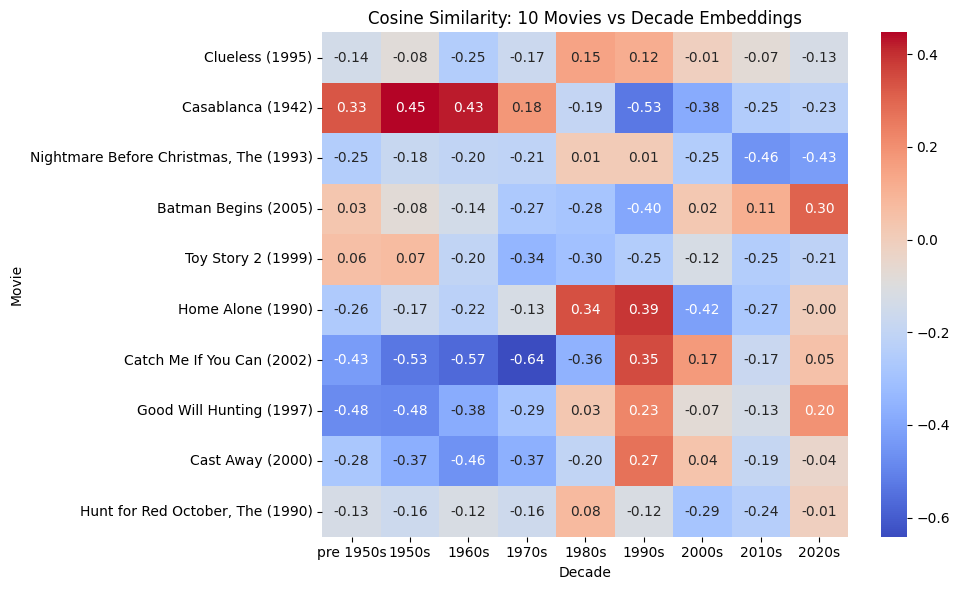

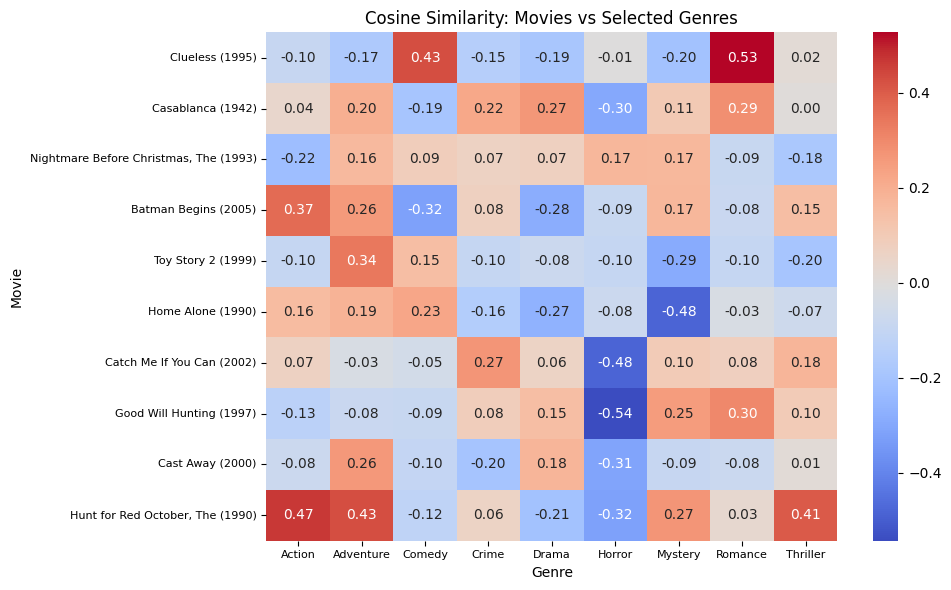

In [9]:
np.random.seed(99)

# Top movies
top_k = 10
top_1000_indices = item_counts.argsort()[::-1][:200]
top_indices = np.random.choice(top_1000_indices, size=top_k, replace=False)
top_embeddings = item_embedding[top_indices]
top_titles = [item_index_to_title[idx] for idx in top_indices]

# Genre subset
subset_genres = [
    "Action", "Adventure", "Comedy", "Crime",
    "Drama", "Horror", "Mystery", "Romance", "Thriller"
]
subset_indices = [i for i, g in enumerate(mlb.classes_) if g in subset_genres]
subset_genre_embedding = genre_embedding[subset_indices, :]
subset_genre_names = [mlb.classes_[i] for i in subset_indices]


# Top movies vs all decades
movie_decade_sim = cosine_similarity(top_embeddings, decade_embedding)
movie_decade_df = pd.DataFrame(movie_decade_sim, index=top_titles, columns=decades)

plt.figure(figsize=(10, 6))
sns.heatmap(movie_decade_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Cosine Similarity: 10 Movies vs Decade Embeddings")
plt.xlabel("Decade")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

# Top movies vs subset of genres
movie_genre_sim = cosine_similarity(top_embeddings, subset_genre_embedding)
movie_genre_df = pd.DataFrame(movie_genre_sim, index=top_titles, columns=subset_genre_names)

plt.figure(figsize=(10, 6))
ax = sns.heatmap(movie_genre_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
plt.title("Cosine Similarity: Movies vs Selected Genres")
plt.xlabel("Genre")
plt.ylabel("Movie")
plt.tight_layout()
plt.show()

### Similarity between movie embeddings

This cell computes pairwise cosine similarity between a randomly selected subset of popular movie embeddings.

The resulting heatmap illustrates how closely related different films are within the learned latent space. Movies with high similarity values are positioned nearby in the embedding representation, suggesting that the model has identified comparable viewing or rating patterns among users.

Such similarities may reflect shared genre structure, thematic overlap, audience preferences, or broader collaborative filtering relationships learned from the ratings data.

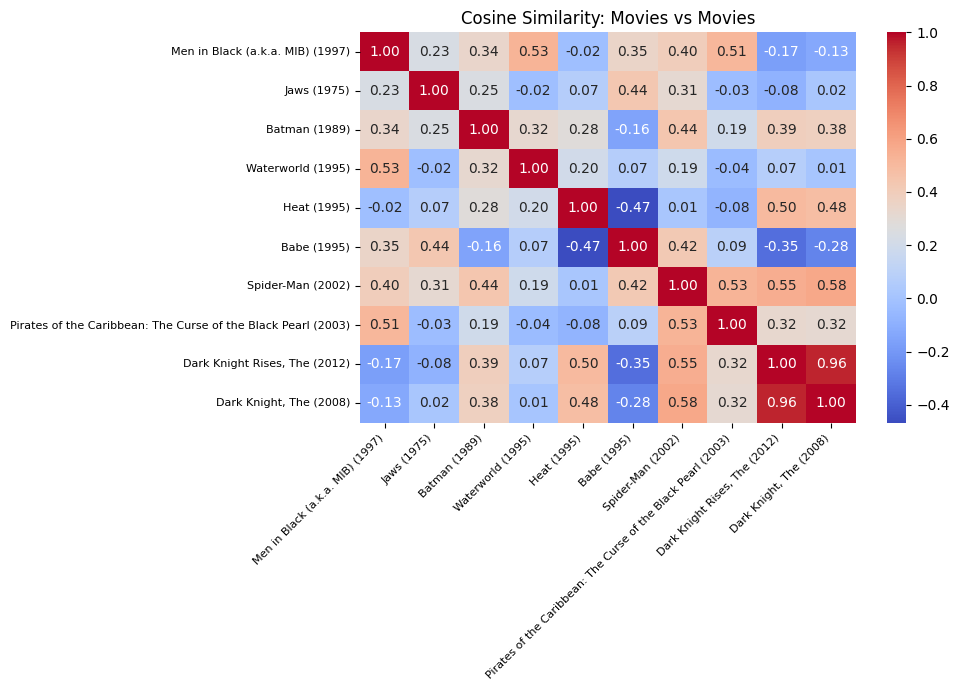

In [10]:
np.random.seed(12)

# Top movies
top_k = 10
top_100_indices = item_counts.argsort()[::-1][:151]
top_indices = np.random.choice(top_100_indices, size=top_k, replace=False)
top_embeddings = item_embedding[top_indices]
top_titles = [item_index_to_title[idx] for idx in top_indices]

# Compute cosine similarity between top movies themselves
movie_movie_sim = cosine_similarity(top_embeddings, top_embeddings)
movie_movie_df = pd.DataFrame(movie_movie_sim, index=top_titles, columns=top_titles)

# Plot heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(movie_movie_df, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.title("Cosine Similarity: Movies vs Movies")
plt.tight_layout()
plt.show()


### Retrieve similar movies from learned embeddings

This cell defines a utility function for identifying movies with similar latent representations using cosine similarity in embedding space.

Given a movie title:
- the title is normalised for robust matching,
- the corresponding movie embedding is located,
- cosine similarity is computed against all other movie embeddings,
- and the top most similar movies are returned.

The resulting recommendations are based purely on relationships learned by the model from collaborative filtering and metadata-informed latent structure, rather than manually specified genre rules or content matching.

In [11]:
from utils import normalize_title

def find_similar_movies(movie_title, top_n=5):
    """
    Find the top N movies most similar to the given movie title
    based on cosine similarity of embeddings.
    
    Parameters:
        movie_title (str): The movie title to search for.
        top_n (int): Number of similar movies to return.
    
    Returns:
        list of tuples: [(title, similarity), ...] or None if movie not found.
    """
    # Normalize input title
    norm_input = normalize_title(movie_title)

    # Find index of the movie
    idx = None
    for i, title in item_index_to_title.items():
        if normalize_title(title) == norm_input:
            idx = i
            break

    if idx is None:
        return None

    # Compute cosine similarity with all movies
    sims = cosine_similarity(item_embedding[idx:idx+1], item_embedding)[0]

    # Get top N similar movies (excluding itself)
    top_indices = sims.argsort()[::-1][1:top_n + 1]
    similar_movies = [
        (item_index_to_title[i], float(round(sims[i], 4))) for i in top_indices
    ]

    return similar_movies

### Example movie similarity query

This cell demonstrates how the learned embedding space can be used to retrieve movie recommendations.

Given a query movie title, the model identifies the most similar films according to cosine similarity between latent item embeddings. The resulting similarities reflect patterns learned from user interactions and feature-informed structure within the recommendation system.

In [12]:
# Select movie
movie_title = "Spider-man"

# Find similar movies
similar_movies = find_similar_movies(movie_title, top_n=20)

# Print header
print(f"{'Movie':50} {'Similarity':>10}")
print("-" * 61)

# Print each similar movie and its similarity
for movie, sim in similar_movies:
    print(f"{movie:50} {sim:10.4f}")

Movie                                              Similarity
-------------------------------------------------------------
Spider-Man 2 (2004)                                    0.9840
X2: X-Men United (2003)                                0.9126
X-Men (2000)                                           0.8594
X-Men: First Class (2011)                              0.8138
Superman Returns (2006)                                0.8057
X-Men: Days of Future Past (2014)                      0.7891
Spider-Man 3 (2007)                                    0.7509
Incredible Hulk, The (2008)                            0.7502
Batman Begins (2005)                                   0.7363
Iron Man (2008)                                        0.7351
Star Trek (2009)                                       0.7350
King Kong (2005)                                       0.7286
Mission: Impossible - Ghost Protocol (2011)            0.7075
Mission: Impossible - Rogue Nation (2015)              0.6986
Amazing 

### Embedding magnitude and polarising movies

This cell investigates the relationship between the magnitude of learned movie embeddings and variability in user ratings.

For movies with a sufficiently large number of ratings, the following quantities are computed:
- embedding magnitude,
- number of ratings,
- and rating standard deviation.

Movies with large rating standard deviations are often considered more *polarising*, since users disagree more strongly in their evaluations.

In latent factor models, a larger embedding magnitude effectively amplifies the contribution of the movie embedding in inner-product interactions with user embeddings. As a result, strongly polarising movies often require larger latent magnitudes so that the model can produce more extreme predicted deviations for different regions of user preference space.

The correlation calculation provides a quantitative measure of the relationship between embedding magnitude and rating variability.

In [ ]:
# Minimum number of ratings to consider
min_ratings = 50_000

# Compute number of ratings and standard deviation per item
item_stats = filtered_data.groupby(filtered_data.columns[1])[filtered_data.columns[2]].agg(
    ['count', 'std']
)

# Filter items with at least `min_ratings`
item_stats = item_stats[item_stats['count'] >= min_ratings]

# Compute embedding magnitude for these items
item_stats['magnitude'] = item_stats.index.to_series().apply(
    lambda idx: np.linalg.norm(item_embedding[idx])
)

# Map item indices to movie titles
item_stats['Movie'] = item_stats.index.to_series().map(item_index_to_title)

# Reorder and rename columns
item_stats = item_stats[['Movie', 'magnitude', 'count', 'std']]
item_stats.columns = ['Movie', 'Embedding Magnitude', 'Num Ratings', 'Rating StdDev']

# Top 10 largest magnitude
top10_largest = item_stats.sort_values(by='Embedding Magnitude', ascending=False).head(10)

# Top 10 smallest magnitude
top10_smallest = item_stats.sort_values(by='Embedding Magnitude', ascending=True).head(10)

# Compute correlation between embedding magnitude and rating standard deviation
corr = item_stats['Embedding Magnitude'].corr(item_stats['Rating StdDev'])

# Display results
print("Top 10 Movies by Embedding Magnitude:")
print(top10_largest.to_string(index=False))

print("\nTop 10 Movies by Smallest Embedding Magnitude:")
print(top10_smallest.to_string(index=False))

print(f"\nCorrelation between embedding magnitude and rating StdDev: {corr:.4f}")

Top 10 Movies by Embedding Magnitude:
                                                    Movie  Embedding Magnitude  Num Ratings  Rating StdDev
    Lord of the Rings: The Return of the King, The (2003)             9.517270        67449       1.010360
            Lord of the Rings: The Two Towers, The (2002)             9.373606        67463       0.997060
Lord of the Rings: The Fellowship of the Ring, The (2001)             9.347728        73122       1.009276
                Star Wars: Episode IV - A New Hope (1977)             7.938498        85010       0.993047
    Star Wars: Episode V - The Empire Strikes Back (1980)             7.666357        72151       0.955928
        Star Wars: Episode VI - Return of the Jedi (1983)             7.541248        67496       0.945215
                                      Pulp Fiction (1994)             7.423832        98409       0.945559
                                       Matrix, The (1999)             6.619014        93808       0.907191